# 4B. Low Field Resonances

## Zeeman resonances and zero field resonance at very low magnetic fields.

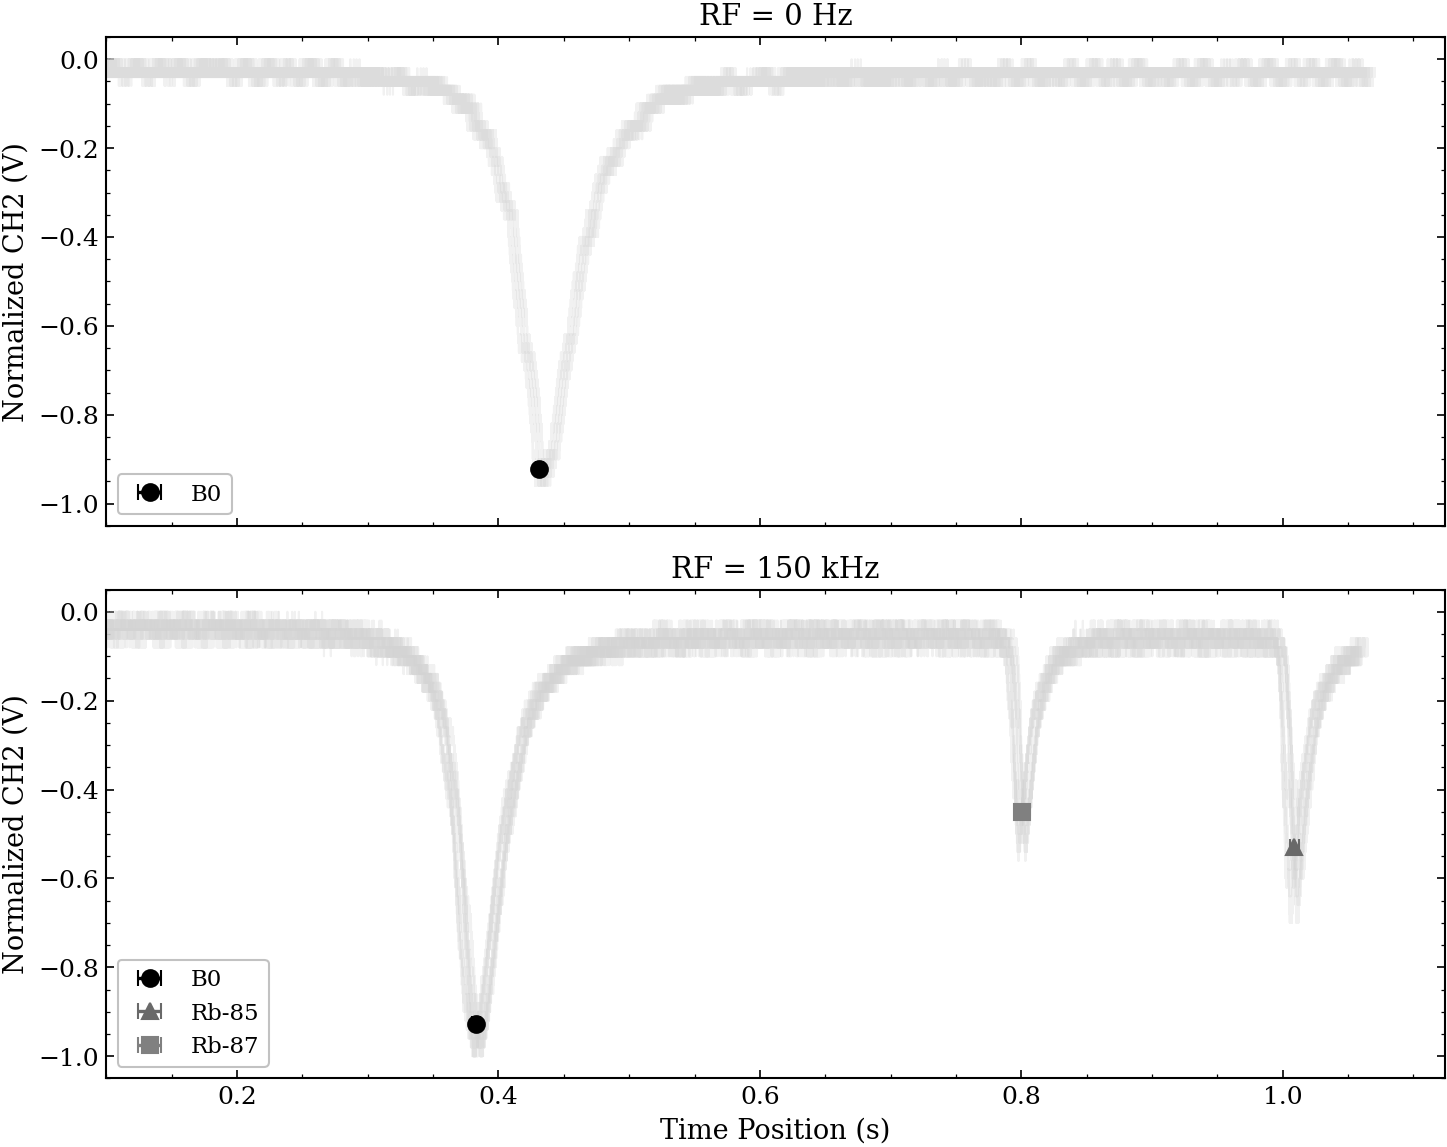

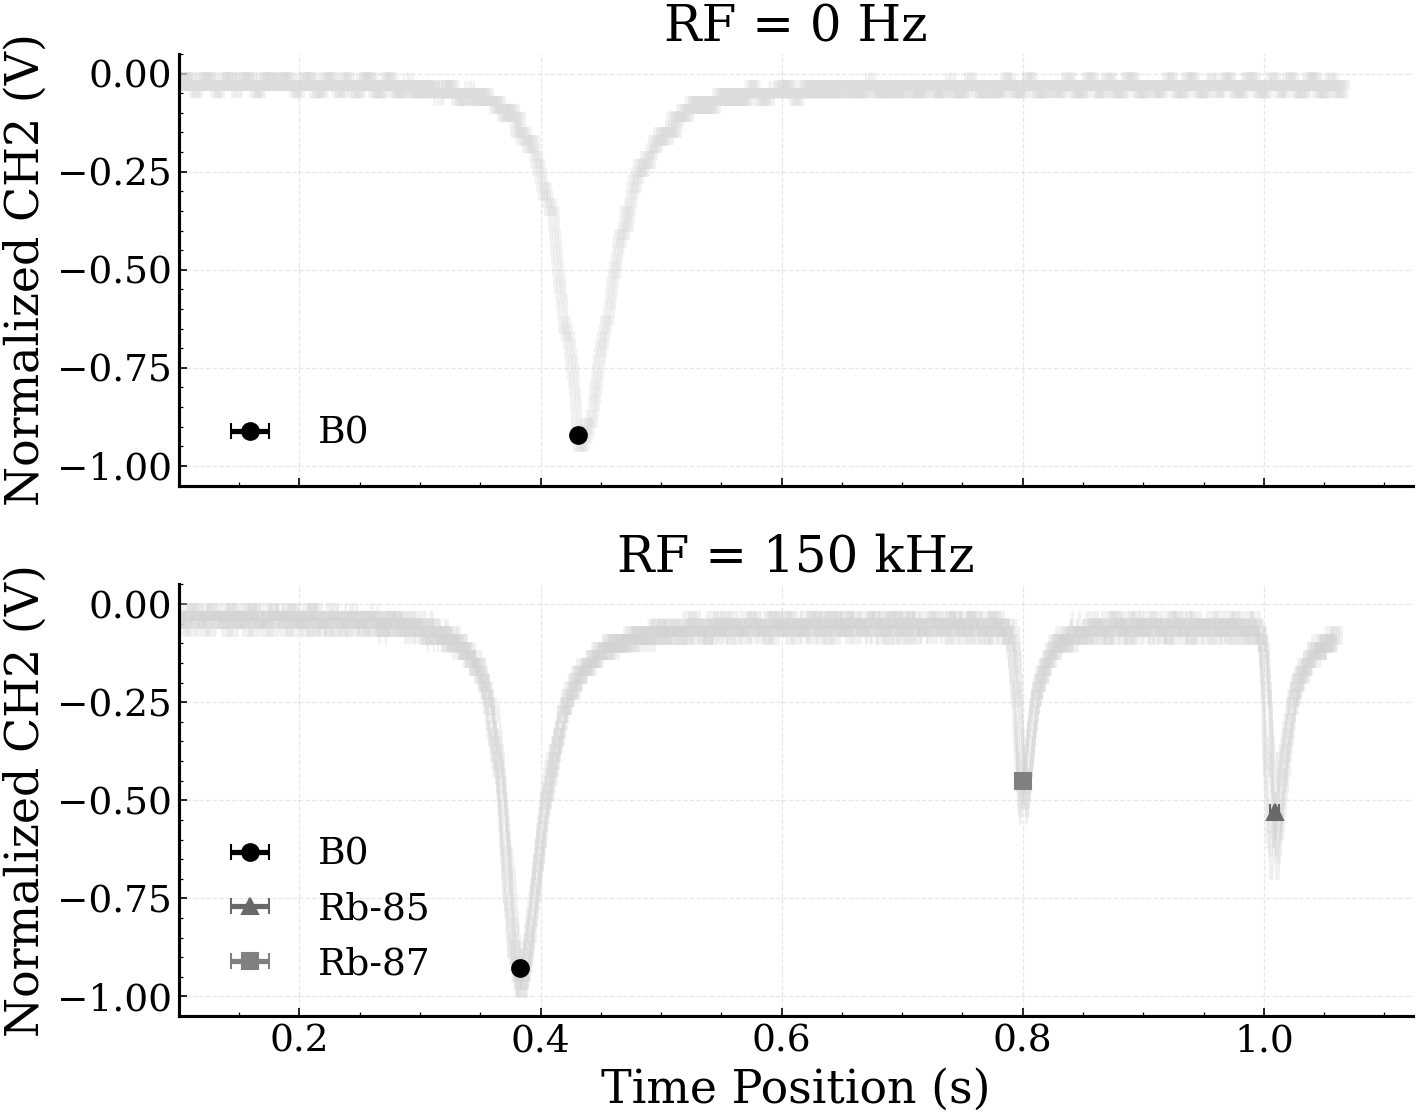

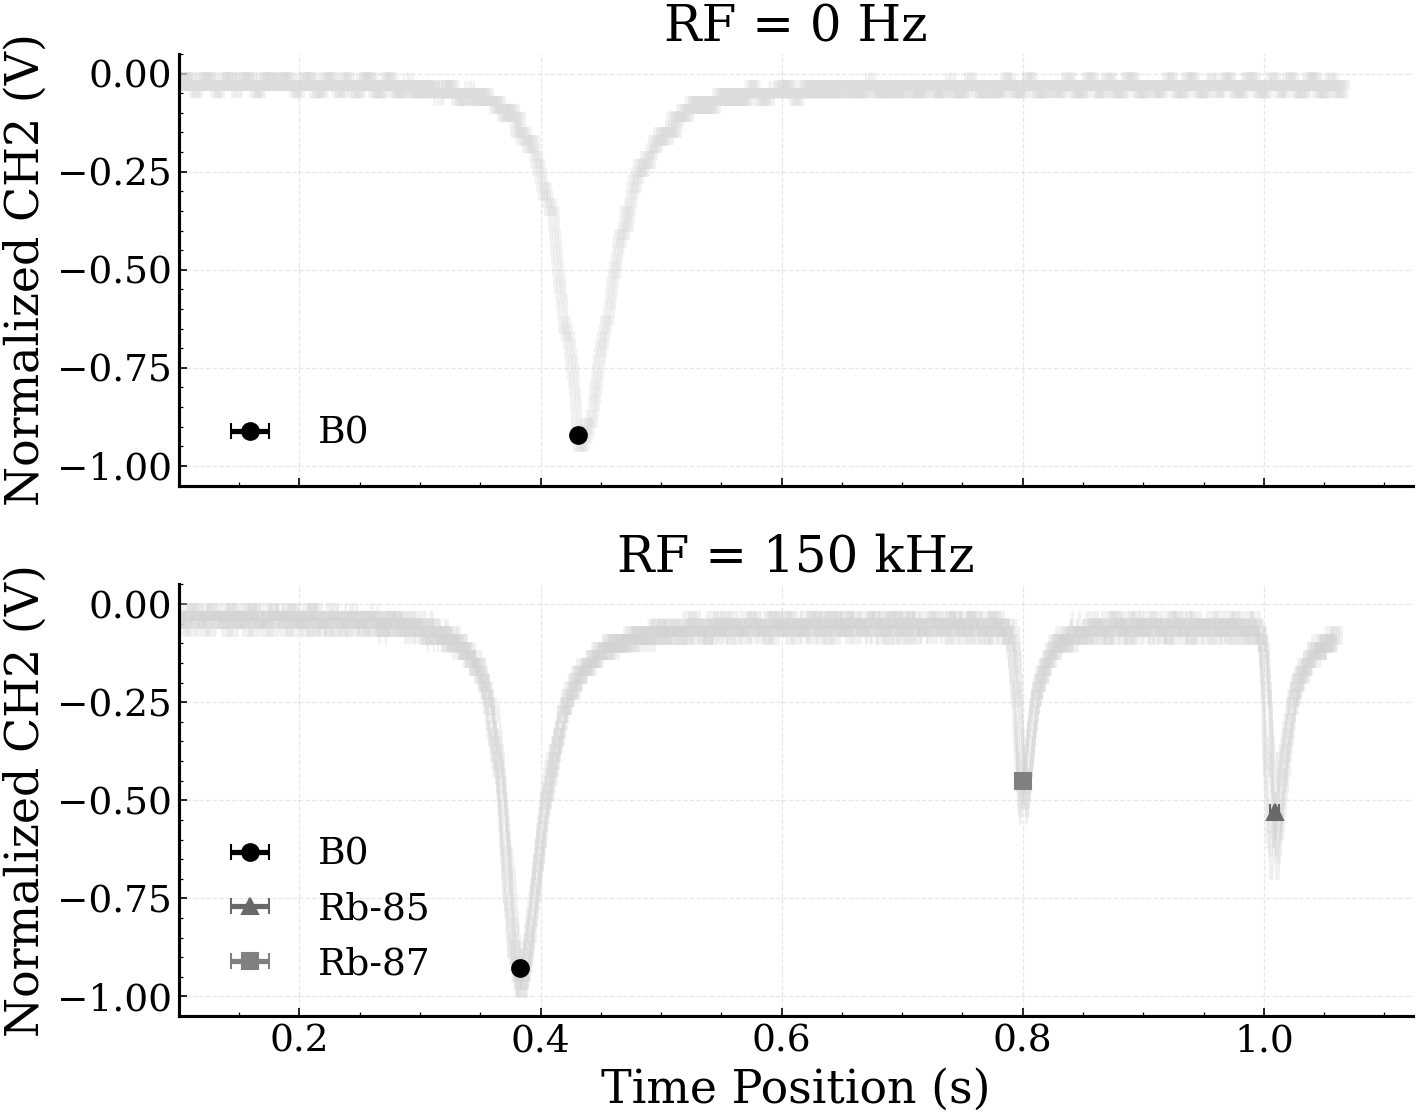

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
from scipy.signal import find_peaks

sys.path.append(os.path.abspath(".."))
from src.visualization.plot_settings import apply_plot_style, save_figure

# 1. 載入整合好的資料 (不再自己做峰值偵測)
df_d2 = pd.read_csv("../data/interim/D2.csv")

# 欲比較的兩個頻率
freqs_to_compare = [0, 150000]

# 原始檔案路徑：用來畫出每個頻率的 sweep 背景，輔助視覺比較
raw_files = {
    0: "../data/raw/D2_Optical_Pumping/0413/B0.csv",
    150000: "../data/raw/D2_Optical_Pumping/0413/150KHZ_RF.csv",
}

# 標記樣式設定 (黑白列印友善)
target_tags = ["B0", "Rb-85", "Rb-87"]
markers = {"B0": "o", "Rb-85": "^", "Rb-87": "s"}
colors = {"B0": "black", "Rb-85": "dimgray", "Rb-87": "gray"}

for style, suffix in [("bw", ""), ("ppt", "_PPT"), ("ppt_bw", "_PPT_BW")]:
    apply_plot_style(style)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)
    axes = {0: ax1, 150000: ax2}

    for freq in freqs_to_compare:
        ax = axes[freq]
        filepath = raw_files[freq]

        # --- 繪製背景原始訊號軌跡 ---
        if os.path.exists(filepath):
            df_raw = pd.read_csv(filepath, skiprows=11)
            df_raw.columns = ["Time (s)", "CH2 (V)", "CH3 (V)"]
            t_raw = df_raw["Time (s)"].values
            ch2 = df_raw["CH2 (V)"].values
            ch3 = df_raw["CH3 (V)"].values

            # 單純利用 CH3 的最大最小值進行週期的定位
            ch3_max_idx, _ = find_peaks(ch3, prominence=1.0, distance=1000)
            ch3_min_idx, _ = find_peaks(-ch3, prominence=1.0, distance=1000)

            for m in ch3_min_idx:
                next_maxs = ch3_max_idx[ch3_max_idx > m]
                if len(next_maxs) > 0:
                    end_idx = next_maxs[0]
                    duration = t_raw[end_idx] - t_raw[m]
                    if 0.8 < duration < 1.2:
                        t_seg = t_raw[m:end_idx]
                        c2_seg = ch2[m:end_idx]

                        # 將波形最高點(基準線)偏移到 0
                        c2_seg_normalized = c2_seg - np.max(c2_seg)

                        # 繪製平移後的訊號，不反轉
                        ax.plot(
                            t_seg - t_seg[0],
                            c2_seg_normalized,
                            color="lightgray",
                            alpha=0.3,
                            lw=1,
                        )

        # --- 從 D2.csv 把已知標記疊加到圖上 ---
        df_freq = df_d2[df_d2["RF freq."] == freq]

        for tag in target_tags:
            df_tag = df_freq[df_freq["tag"] == tag]

            # 限制範圍 x >= 0.1
            df_tag = df_tag[df_tag["time position"] >= 0.1]

            if df_tag.empty:
                continue

            # x 為時間範圍, y 為 -dip depth (向下標記)，利用已知的不確定度加入水平誤差棒
            x = df_tag["time position"].values
            xerr = df_tag["time uncertainty"].values
            y = -df_tag["dip depth"].values

            ax.errorbar(
                x,
                y,
                xerr=xerr,
                fmt=markers[tag],
                color=colors[tag],
                label=tag,
                capsize=4,
                markersize=8,
                zorder=5,
            )

        freq_label = "0 Hz" if freq == 0 else f"{freq//1000} kHz"
        ax.set_title(f"RF = {freq_label}")
        ax.set_ylabel("Normalized CH2 (V)")

        # 強制限制 X 軸呈現範圍
        ax.set_xlim(left=0.1)

        # 解決疊加時會重複渲染 Legend 標籤的問題, 改到左下角
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        if unique:
            ax.legend(unique.values(), unique.keys(), loc="lower left")

    ax2.set_xlabel("Time Position (s)")
    plt.tight_layout()
    save_figure(
        fig, f"4b_raw_traces_comparison{suffix}.pdf", directory="../reports/figures"
    )
    plt.show()

## Measurement of the Nuclear Spins

In [2]:
import pandas as pd
import numpy as np

# 讀取實際整合好的數據
df = pd.read_csv("../data/interim/D2.csv")

# 常數設定
N = 11
R = 0.1639  # 單位：公尺
mu0_h = 1.3996  # 單位：MHz/Gauss


# 磁場計算公式
def calc_B(I):
    return (8.991e-3 * I * N) / R


# 1. 找出剩餘磁場對應的電流 (取 RF freq. = 0Hz 且 tag = B0)
i_res = df[(df["RF freq."] == 0) & (df["tag"] == "B0")]["CH3 current"].values[0]
B_res = calc_B(i_res)

print(f"Zero Field Resonance Current (i_res): {i_res:.4f} A")
print(f"Residual Magnetic Field (B_res): {B_res:.4f} Gauss\n")


# 定義核自旋判定邏輯
def determine_and_print(g_f, b_net, current, label):
    print(f"--- {label} (I = {current:.4f} A) ---")
    print(f"Net Magnetic Field: {b_net:.4f} Gauss")
    print(f"Calculated g_F: {g_f:.4f}")

    if abs(g_f - 0.33) <= 0.08:
        print("判定結果: Rb-85 (核自旋 I = 5/2)")
    elif abs(g_f - 0.50) <= 0.08:
        print("判定結果: Rb-87 (核自旋 I = 3/2)")
    else:
        print("判定結果: 未知同位素")


# 2. 選取低頻區間的資料進行核自旋計算 (以 70kHz 到 150kHz 為例)
test_freqs = [70000, 90000, 110000, 130000, 150000]

for freq in test_freqs:
    print(f"========== RF Frequency: {freq / 1000:.1f} kHz ==========")

    # 取出該頻率資料
    df_rf = df[df["RF freq."] == freq]

    # 確保含有這兩種同位素的標記資料
    rb85_data = df_rf[df_rf["tag"] == "Rb-85"]
    rb87_data = df_rf[df_rf["tag"] == "Rb-87"]

    if rb85_data.empty or rb87_data.empty:
        print("缺少 Rb-85 或 Rb-87 資料，略過...\n")
        continue

    # 取出對應的 sweep 電流
    i_iso1 = rb85_data["CH3 current"].values[0]
    i_iso2 = rb87_data["CH3 current"].values[0]

    # 計算淨磁場 (使用絕對值避免反向相減產生負數)
    B_net1 = np.abs(calc_B(i_iso1) - B_res)
    B_net2 = np.abs(calc_B(i_iso2) - B_res)

    # 換算頻率為 MHz 並計算 g_F
    v_mhz = freq / 1e6
    g_F1 = v_mhz / (mu0_h * B_net1)
    g_F2 = v_mhz / (mu0_h * B_net2)

    # 列印結果
    determine_and_print(g_F1, B_net1, i_iso1, "Peak 1 (標記為 Rb-85)")
    determine_and_print(g_F2, B_net2, i_iso2, "Peak 2 (標記為 Rb-87)")
    print("\n")

Zero Field Resonance Current (i_res): 0.3688 A
Residual Magnetic Field (B_res): 0.2225 Gauss

========== RF Frequency: 70.0 kHz ==========
--- Peak 1 (標記為 Rb-85) (I = 0.5764 A) ---
Net Magnetic Field: 0.1253 Gauss
Calculated g_F: 0.3992
判定結果: Rb-85 (核自旋 I = 5/2)
--- Peak 2 (標記為 Rb-87) (I = 0.4934 A) ---
Net Magnetic Field: 0.0752 Gauss
Calculated g_F: 0.6650
判定結果: 未知同位素


========== RF Frequency: 90.0 kHz ==========
--- Peak 1 (標記為 Rb-85) (I = 0.6490 A) ---
Net Magnetic Field: 0.1691 Gauss
Calculated g_F: 0.3803
判定結果: Rb-85 (核自旋 I = 5/2)
--- Peak 2 (標記為 Rb-87) (I = 0.5457 A) ---
Net Magnetic Field: 0.1067 Gauss
Calculated g_F: 0.6025
判定結果: 未知同位素


========== RF Frequency: 110.0 kHz ==========
--- Peak 1 (標記為 Rb-85) (I = 0.7258 A) ---
Net Magnetic Field: 0.2154 Gauss
Calculated g_F: 0.3648
判定結果: Rb-85 (核自旋 I = 5/2)
--- Peak 2 (標記為 Rb-87) (I = 0.5957 A) ---
Net Magnetic Field: 0.1369 Gauss
Calculated g_F: 0.5739
判定結果: Rb-87 (核自旋 I = 3/2)


========== RF Frequency: 130.0 kHz ==========
--

## Low field Zeeman effect

=== Rb-85 ===
Slope = 0.2981+/-0.0023 MHz/A
Intercept = -0.1063+/-0.0015 MHz

=== Rb-87 ===
Slope = 0.463+/-0.006 MHz/A
Intercept = -0.1657+/-0.0031 MHz

Ratio of slopes (Rb-87 / Rb-85) = 1.554+/-0.022



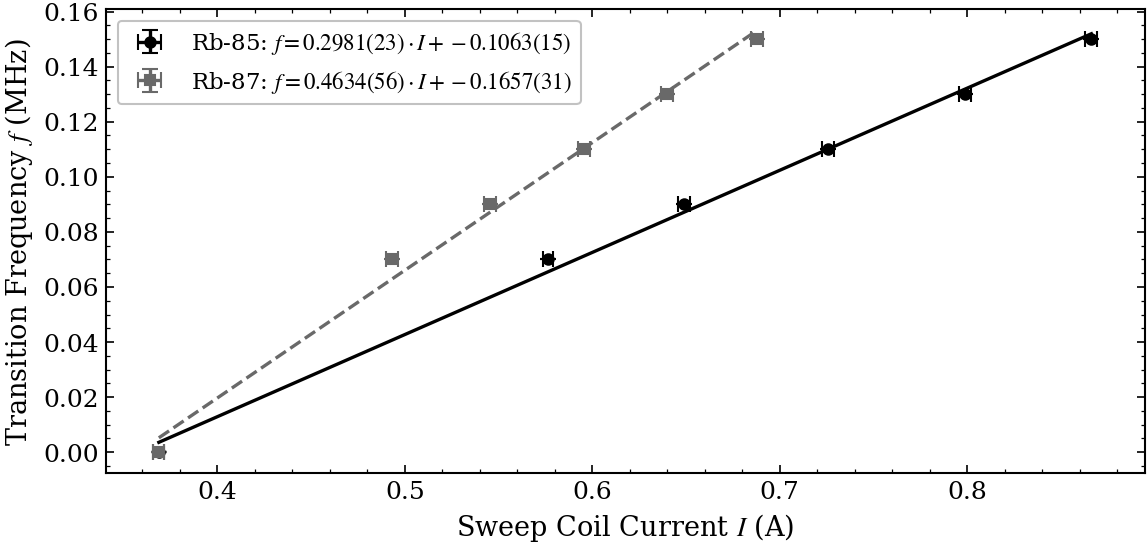

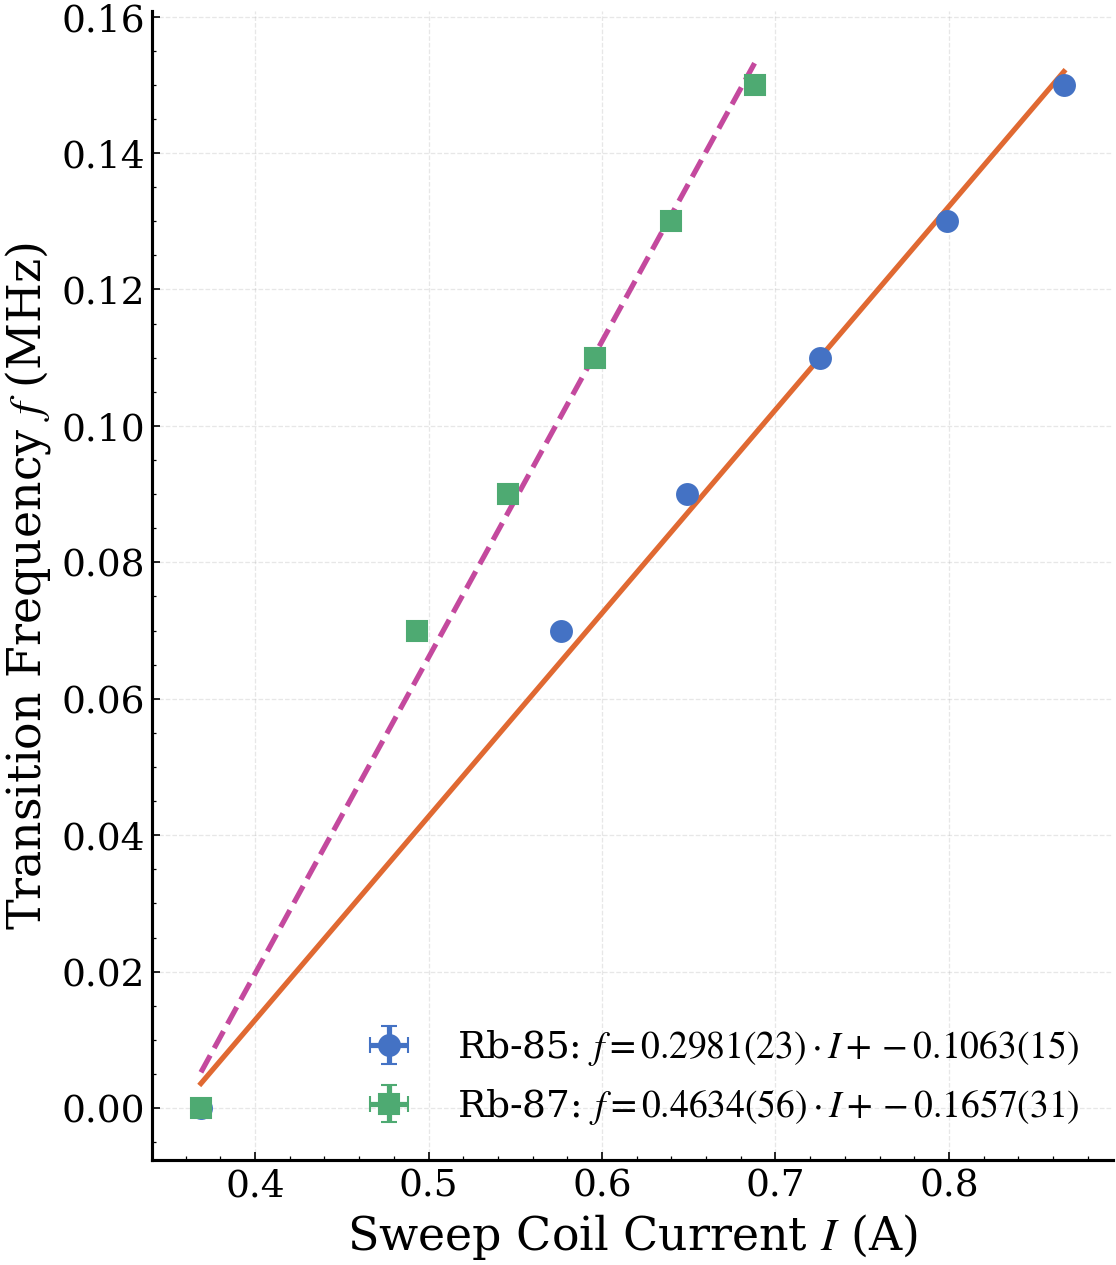

=== Rb-85 ===
Slope = 0.2981+/-0.0023 MHz/A
Intercept = -0.1063+/-0.0015 MHz

=== Rb-87 ===
Slope = 0.463+/-0.006 MHz/A
Intercept = -0.1657+/-0.0031 MHz

Ratio of slopes (Rb-87 / Rb-85) = 1.554+/-0.022



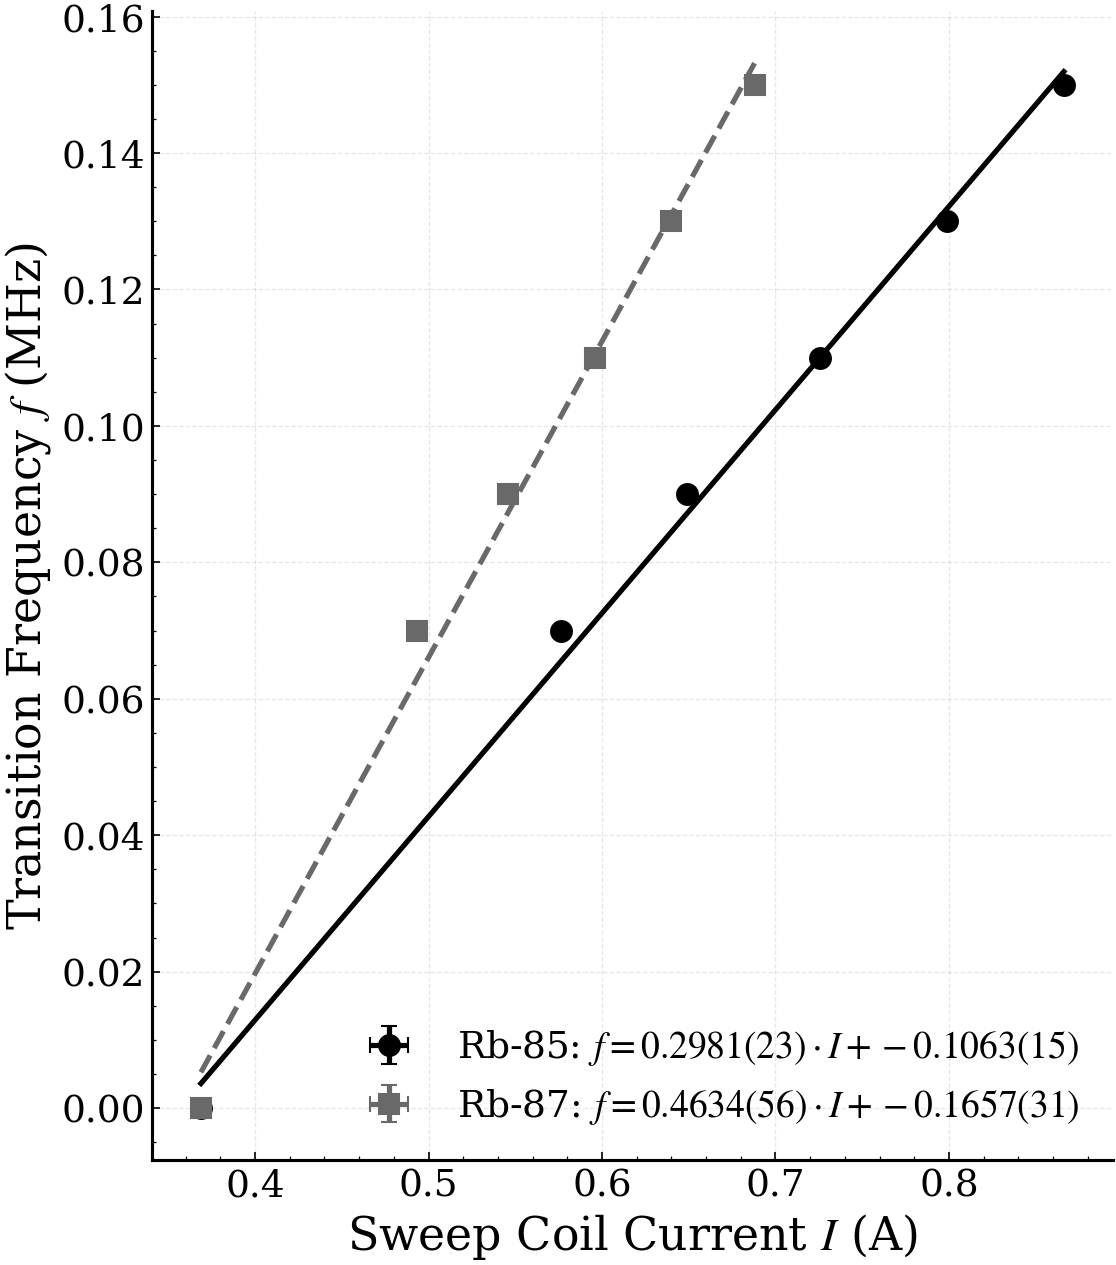

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))
from src.analysis.fitting import excel_style_regression_with_propagation
from src.analysis.formatting import ufloat_to_paren
from src.visualization.plot_settings import apply_plot_style, save_figure

# 1. Load data
df_d2 = pd.read_csv("../data/interim/D2.csv")

# 2. Filter data
target_freqs = [70000, 90000, 110000, 130000, 150000]
df_rf = df_d2[df_d2["RF freq."].isin(target_freqs)].copy()
df_0 = df_d2[df_d2["RF freq."] == 0].copy()

# 轉換為 MHz
df_rf["RF freq. MHz"] = df_rf["RF freq."] / 1e6
df_rf["RF freq. uncertainty MHz"] = 0.0

df_0["RF freq. MHz"] = 0.0
df_0["RF freq. uncertainty MHz"] = 0.0

tags = ["Rb-85", "Rb-87"]
# 黑白友善的設定：使用不同的 marker (圓形 vs 方形)、線條樣式 (實線 vs 虛線) 以及黑灰顏色
markers = {"Rb-85": "o", "Rb-87": "s"}
linestyles = {"Rb-85": "-", "Rb-87": "--"}
colors = {"Rb-85": "black", "Rb-87": "dimgray"}

for style, suffix in [("bw", ""), ("ppt", "_PPT"), ("ppt_bw", "_PPT_BW")]:
    apply_plot_style(style)
    fig, ax = plt.subplots(figsize=(8, 4) if style == "bw" else (8, 9))

    slopes = {}

    for tag in tags:
        # 取得大於 0Hz 的相應同位素數據，並合併 0Hz 數據
        df_tag = df_rf[df_rf["tag"] == tag].copy()
        df_tag = pd.concat([df_tag, df_0], ignore_index=True)
        df_tag = df_tag.sort_values("CH3 current")

        if df_tag.empty:
            continue

        x = df_tag["CH3 current"].values
        sigma_x = df_tag["CH3 current uncertainty"].values
        y = df_tag["RF freq. MHz"].values
        sigma_y = df_tag["RF freq. uncertainty MHz"].values

        # 進行迴歸與不確定度傳遞
        slope, intercept = excel_style_regression_with_propagation(
            x, y, sigma_x, sigma_y
        )

        slopes[tag] = slope

        # 格式化方程式文字
        eq_label = f"{tag}: $f = {ufloat_to_paren(slope)} \\cdot I + {ufloat_to_paren(intercept)}$"

        if "bw" in style:
            print(f"=== {tag} ===")
            print(f"Slope = {slope} MHz/A")
            print(f"Intercept = {intercept} MHz")
            print()

        # 畫點 (含有誤差棒)，將方程式直接顯示於圖例(Legend)中
        ax.errorbar(
            x,
            y,
            xerr=sigma_x,
            yerr=sigma_y,
            fmt=markers[tag],
            color=colors[tag] if "bw" in style else None,
            label=eq_label,
            capsize=4,
        )

        # 畫擬合線
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = slope.nominal_value * x_fit + intercept.nominal_value
        ax.plot(
            x_fit,
            y_fit,
            linestyle=linestyles[tag],
            color=colors[tag] if "bw" in style else None,
        )

    # 計算斜率比值
    if "Rb-85" in slopes and "Rb-87" in slopes:
        ratio = slopes["Rb-87"] / slopes["Rb-85"]
        if "bw" in style:
            print(f"Ratio of slopes (Rb-87 / Rb-85) = {ratio}")
            print()

    ax.set_xlabel("Sweep Coil Current $I$ (A)")
    ax.set_ylabel("Transition Frequency $f$ (MHz)")
    # ax.set_title("Low Field Zeeman Resonances")
    ax.set_title("")
    ax.legend()
    plt.tight_layout()
    save_figure(fig, f"4b_low_field_zeeman{suffix}.pdf", directory="../reports/figures")
    plt.show()

## Sweep field calibration

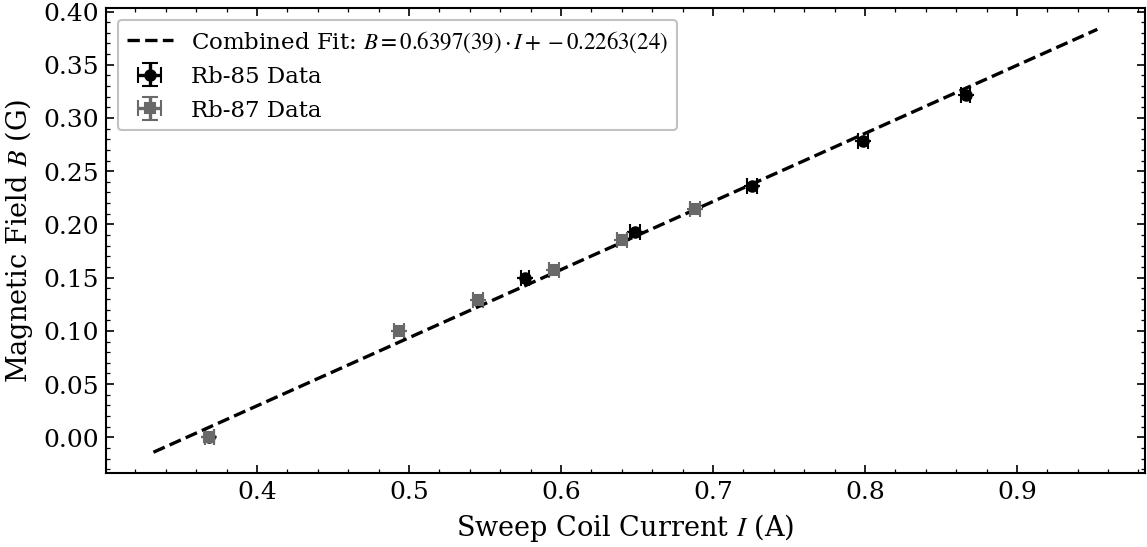

=== Sweep Field Calibration ===
Slope: 0.640+/-0.004 G/A
Intercept: -0.2263+/-0.0024 G


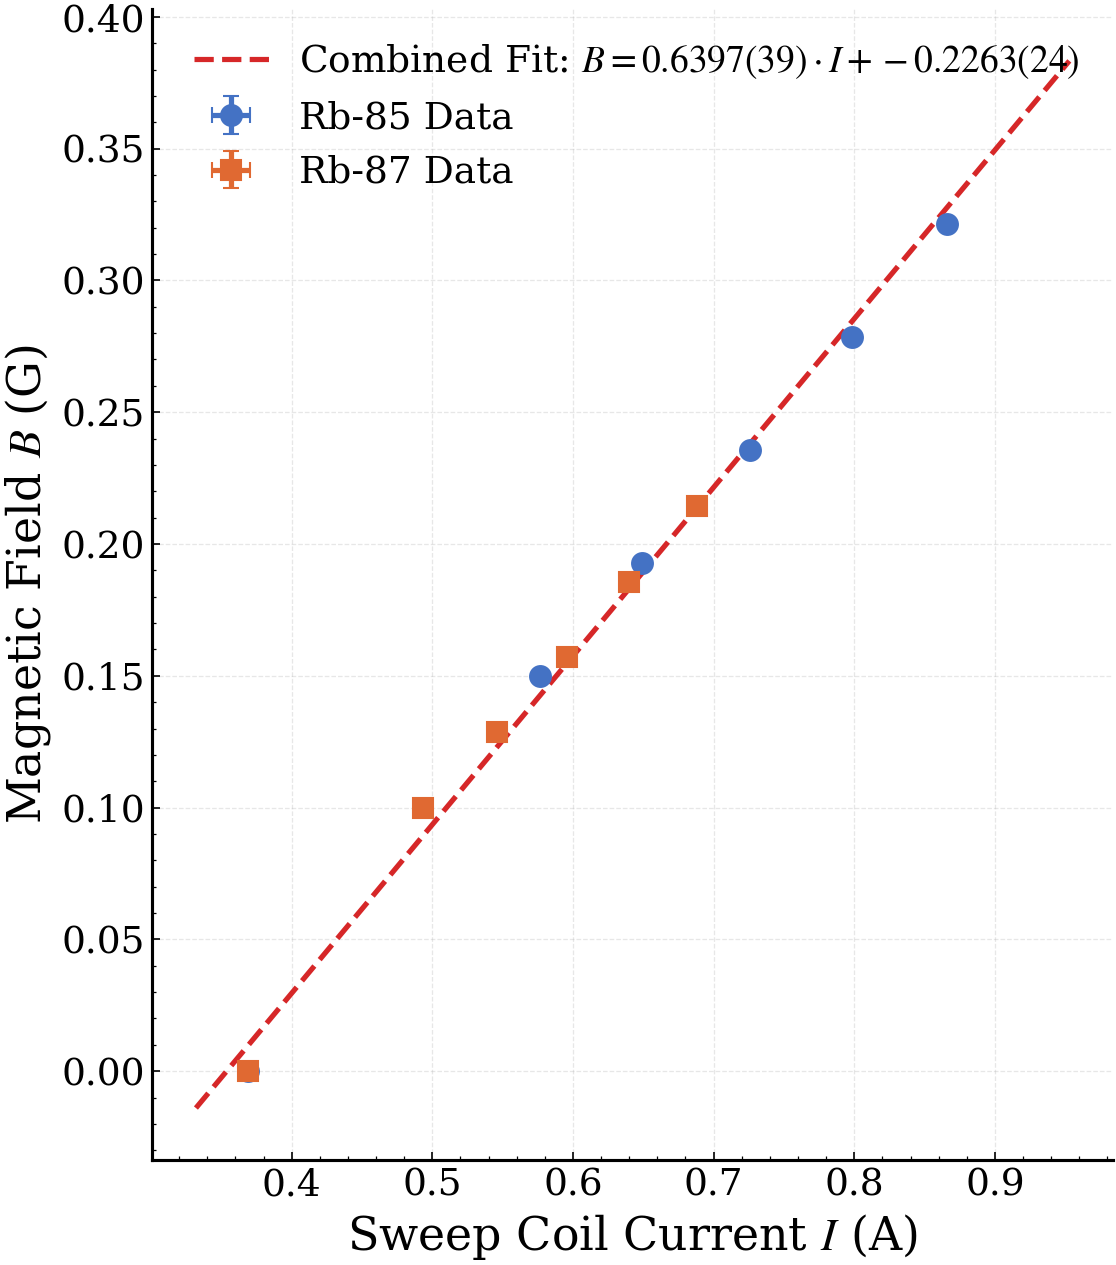

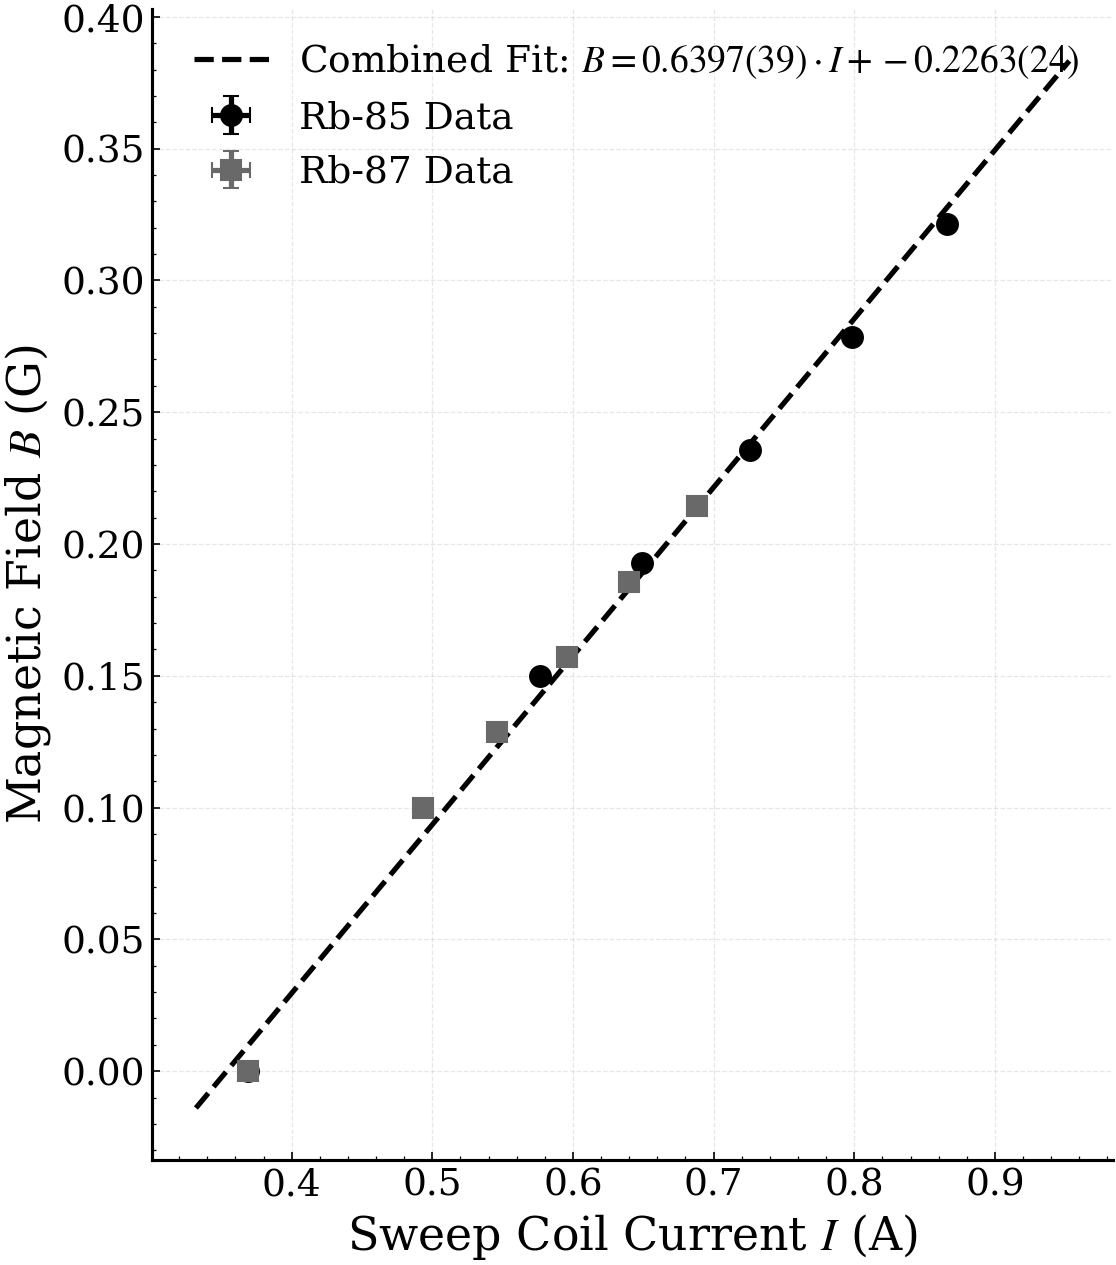

=== Sweep Field Calibration ===
Slope: 0.640+/-0.004 G/A
Intercept: -0.2263+/-0.0024 G


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))
from src.analysis.fitting import excel_style_regression_with_propagation
from src.analysis.formatting import ufloat_to_paren
from src.visualization.plot_settings import apply_plot_style, save_figure

# 物理常數
mu_b = 9.274009994e-28  # J/G
h = 6.62607015e-34  # J·s

# 理論 g_F
g_F_dict = {"Rb-85": 1 / 3, "Rb-87": 1 / 2}

# 1. Load data
df_d2 = pd.read_csv("../data/interim/D2.csv")

# 2. Filter data
target_freqs = [70000, 90000, 110000, 130000, 150000]
df_rf = df_d2[df_d2["RF freq."].isin(target_freqs)].copy()
df_0 = df_d2[df_d2["RF freq."] == 0].copy()

tags = ["Rb-85", "Rb-87"]
markers = {"Rb-85": "o", "Rb-87": "s"}
colors = {"Rb-85": "black", "Rb-87": "dimgray"}

for style, suffix in [("bw", ""), ("ppt", "_PPT"), ("ppt_bw", "_PPT_BW")]:
    apply_plot_style(style)
    fig, ax = plt.subplots(figsize=(8, 4) if style == "bw" else (8, 9))

    # 準備容器用以合併變數做單一擬合
    combined_currents = []
    combined_currents_err = []
    combined_B = []
    combined_B_err = []

    for tag in tags:
        # 取出該同位素的資料，並合併 0Hz 數據
        df_tag = df_rf[df_rf["tag"] == tag].copy()
        df_tag = pd.concat([df_tag, df_0], ignore_index=True)
        df_tag = df_tag.sort_values("CH3 current")

        if df_tag.empty:
            continue

        freqs = df_tag["RF freq."].values
        # 假設 RF freq. 不確定度小到可忽略
        freqs_err = np.zeros_like(freqs)

        # 取得 Sweep Coil Current 與其誤差
        I = df_tag["CH3 current"].values
        I_err = df_tag["CH3 current uncertainty"].values

        # 計算 Magnetic field B (G)
        # B = RF_freq * h / (g_F * mu_b)
        B = freqs * h / (g_F_dict[tag] * mu_b)
        B_err = freqs_err * h / (g_F_dict[tag] * mu_b)

        # 存入共用列表作後續 fit
        combined_currents.extend(I)
        combined_currents_err.extend(I_err)
        combined_B.extend(B)
        combined_B_err.extend(B_err)

        # 畫點 (含有誤差棒)
        ax.errorbar(
            I,
            B,
            xerr=I_err,
            yerr=B_err,
            fmt=markers[tag],
            color=colors[tag] if "bw" in style else None,
            label=f"{tag} Data",
            capsize=4,
        )

    # 轉換型別以進行擬合
    combined_currents = np.array(combined_currents)
    combined_currents_err = np.array(combined_currents_err)
    combined_B = np.array(combined_B)
    combined_B_err = np.array(combined_B_err)

    # 單一線性擬合：結合所有 Rb-85, Rb-87 與 0Hz 之參數校正
    slope_B, intercept_B = excel_style_regression_with_propagation(
        x=combined_currents,
        y=combined_B,
        sigma_x=combined_currents_err,
        sigma_y=combined_B_err,
    )

    # 繪製單一擬合線，並套用 formatting
    x_fit = np.linspace(
        combined_currents.min() * 0.9, combined_currents.max() * 1.1, 100
    )
    y_fit = slope_B.nominal_value * x_fit + intercept_B.nominal_value

    eq_label = f"Combined Fit: $B = {ufloat_to_paren(slope_B)} \\cdot I + {ufloat_to_paren(intercept_B)}$"
    ax.plot(
        x_fit,
        y_fit,
        linestyle="--",
        color="black" if "bw" in style else "tab:red",
        label=eq_label,
    )

    ax.set_xlabel("Sweep Coil Current $I$ (A)")
    ax.set_ylabel("Magnetic Field $B$ (G)")
    # ax.set_title("Sweep Field Calibration: Magnetic Field vs. Sweep Coil Current")
    ax.set_title("")
    ax.legend()
    plt.tight_layout()
    save_figure(
        fig, f"4b_sweep_field_calibration{suffix}.pdf", directory="../reports/figures"
    )
    plt.show()

    if "bw" in style:
        print("=== Sweep Field Calibration ===")
        print(f"Slope: {slope_B} G/A")
        print(f"Intercept: {intercept_B} G")

/Users/dengensheng/Developer/D2_Optical_Pumping/.venv/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/Users/dengensheng/Developer/D2_Optical_Pumping/.venv/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


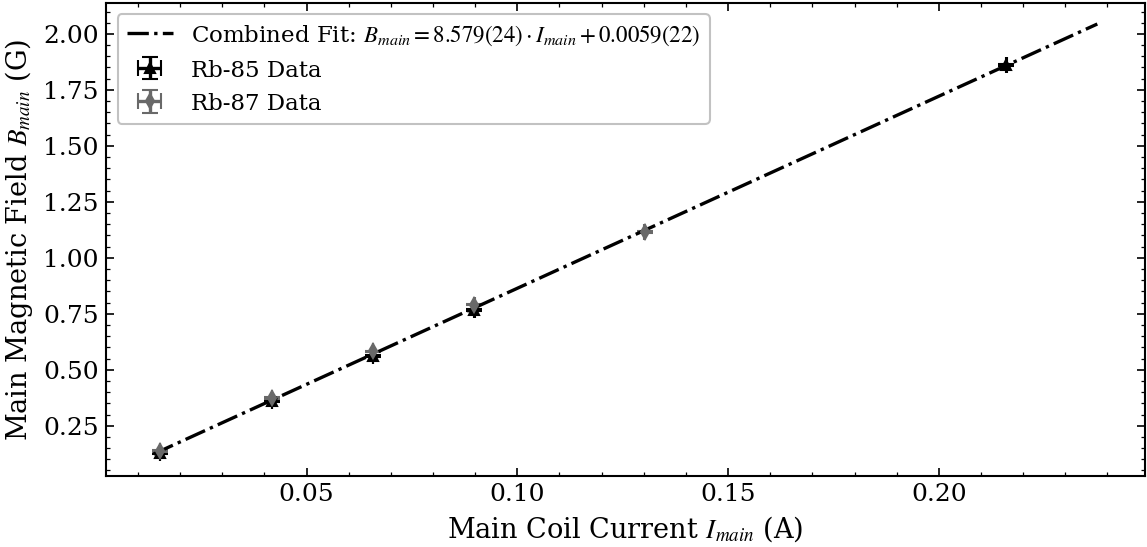

=== Main Field Calibration ===
Slope: 8.579+/-0.024 G/A
Intercept: 0.0059+/-0.0022 G


/Users/dengensheng/Developer/D2_Optical_Pumping/.venv/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/Users/dengensheng/Developer/D2_Optical_Pumping/.venv/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


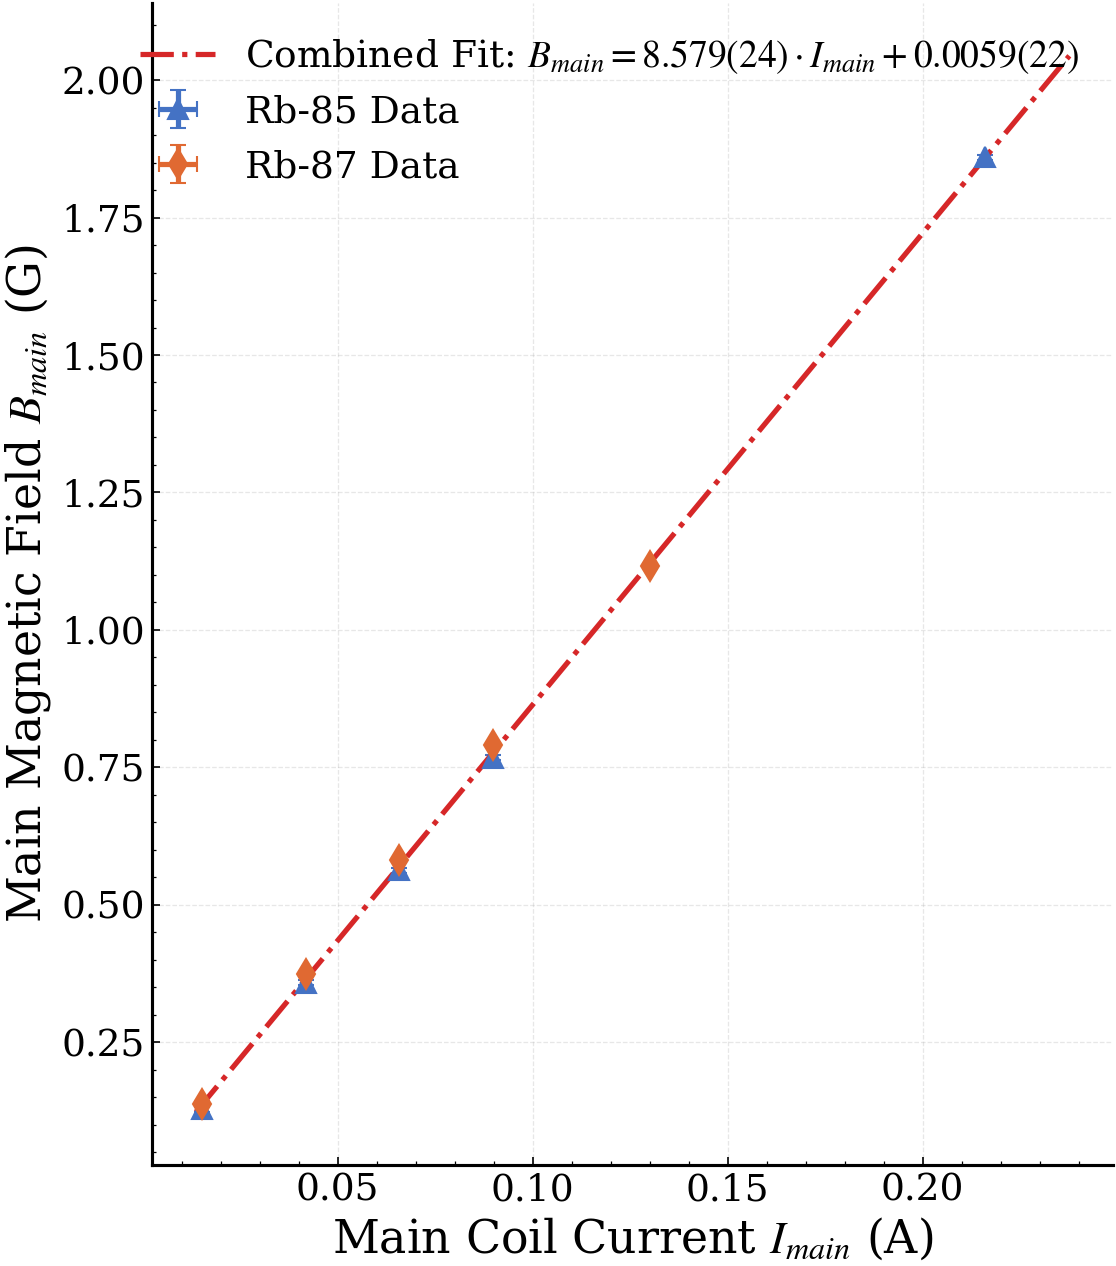

/Users/dengensheng/Developer/D2_Optical_Pumping/.venv/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/Users/dengensheng/Developer/D2_Optical_Pumping/.venv/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


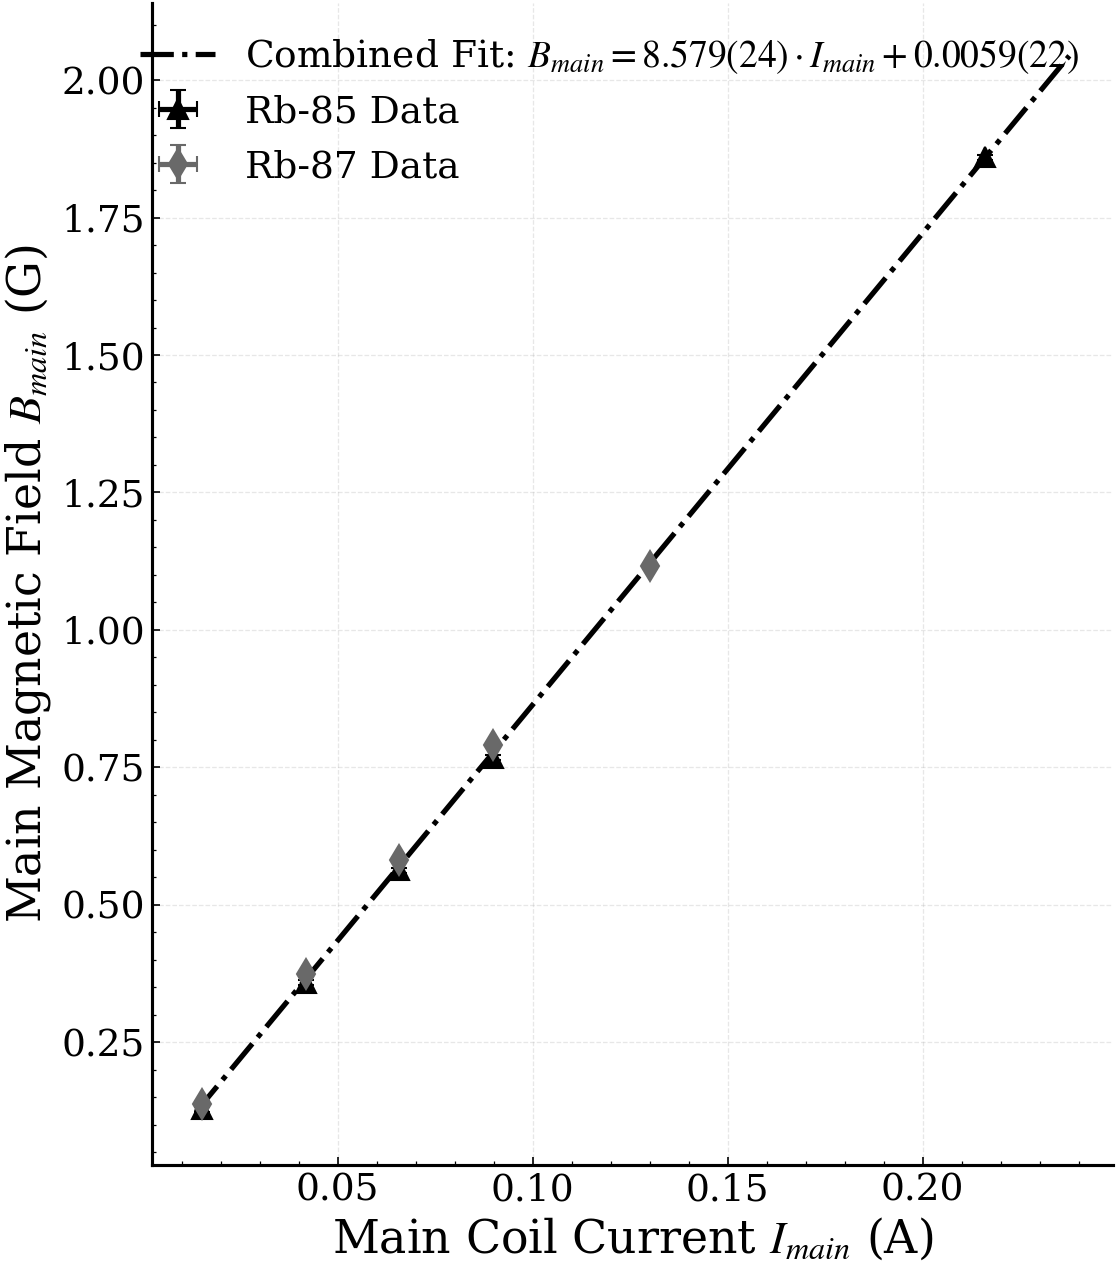

=== Main Field Calibration ===
Slope: 8.579+/-0.024 G/A
Intercept: 0.0059+/-0.0022 G
Saved calibration parameters to ../data/interim/calibration.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from uncertainties import ufloat

sys.path.append(os.path.abspath(".."))
from src.analysis.fitting import excel_style_regression_with_propagation
from src.analysis.formatting import ufloat_to_paren
from src.visualization.plot_settings import apply_plot_style, save_figure

# 物理常數
mu_b = 9.274009994e-28  # J/G
h = 6.62607015e-34  # J·s

# 理論 g_F
g_F_dict = {"Rb-85": 1 / 3, "Rb-87": 1 / 2}

# 1. Load data
df_d2 = pd.read_csv("../data/interim/D2.csv")

# 2. Filter data: 針對主磁場的測試，選取頻率 >= 200kHz (亦即 200000 Hz)
df_main = df_d2[df_d2["RF freq."] >= 200000].copy()

tags = ["Rb-85", "Rb-87"]
# 使用與上個 cell 不同的 marker，同時保持黑白友善
markers = {"Rb-85": "^", "Rb-87": "d"}
colors = {"Rb-85": "black", "Rb-87": "dimgray"}

for style, suffix in [("bw", ""), ("ppt", "_PPT"), ("ppt_bw", "_PPT_BW")]:
    apply_plot_style(style)
    fig, ax = plt.subplots(figsize=(8, 4) if style == "bw" else (8, 9))

    # 準備容器用以合併變數做單一擬合
    combined_I_main = []
    combined_I_main_err = []
    combined_B_main = []
    combined_B_main_err = []

    for tag in tags:
        df_tag = df_main[df_main["tag"] == tag].sort_values("main field current")
        if df_tag.empty:
            continue

        freqs = df_tag["RF freq."].values
        freqs_err = np.zeros_like(freqs)

        # 取得 Sweep Coil Current (用於扣除環境磁場與 sweep 電流造成的場)
        I_sweep = df_tag["CH3 current"].values
        I_sweep_err = df_tag["CH3 current uncertainty"].values

        # 取得 Main Coil Current 也就是橫軸 x
        I_main = df_tag["main field current"].values
        I_main_err = df_tag["main field current uncertainty"].values

        # 計算此時實驗環境下的總磁場 B_total
        # B_total = freqs * h / (g_F * mu_b)
        B_tot = freqs * h / (g_F_dict[tag] * mu_b)
        B_tot_err = freqs_err * h / (g_F_dict[tag] * mu_b)

        # 扣除由 Sweep Coil 產生之磁場以及地磁背景 (利用上個 cell 算出的 slope_B, intercept_B ufloat 物件)
        # B_main = B_total - (slope_B * I_sweep + intercept_B)
        B_main_vals = []
        B_main_errs = []

        for i in range(len(I_sweep)):
            # 轉換為 ufloat 以自動計算誤差傳遞
            u_I_sweep = ufloat(I_sweep[i], I_sweep_err[i])
            u_B_tot = ufloat(B_tot[i], B_tot_err[i])

            # 扣除 Sweep Field 與 B0 intercept
            u_B_main = u_B_tot - (slope_B * u_I_sweep + intercept_B)

            B_main_vals.append(u_B_main.nominal_value)
            B_main_errs.append(u_B_main.std_dev)

        B_main_vals = np.array(B_main_vals)
        B_main_errs = np.array(B_main_errs)

        # 存入共用列表作後續綜合 fit
        combined_I_main.extend(I_main)
        combined_I_main_err.extend(I_main_err)
        combined_B_main.extend(B_main_vals)
        combined_B_main_err.extend(B_main_errs)

        # 畫點 (含有誤差棒)
        ax.errorbar(
            I_main,
            B_main_vals,
            xerr=I_main_err,
            yerr=B_main_errs,
            fmt=markers[tag],
            color=colors[tag] if "bw" in style else None,
            label=f"{tag} Data",
            capsize=4,
        )

    # 轉換型別以進行擬合
    combined_I_main = np.array(combined_I_main)
    combined_I_main_err = np.array(combined_I_main_err)
    combined_B_main = np.array(combined_B_main)
    combined_B_main_err = np.array(combined_B_main_err)

    # 單一線性擬合：B_main vs. I_main
    slope_main, intercept_main = excel_style_regression_with_propagation(
        x=combined_I_main,
        y=combined_B_main,
        sigma_x=combined_I_main_err,
        sigma_y=combined_B_main_err,
    )

    # 繪製單一擬合線，並套用 formatting
    x_fit = np.linspace(combined_I_main.min() * 0.9, combined_I_main.max() * 1.1, 100)
    y_fit = slope_main.nominal_value * x_fit + intercept_main.nominal_value

    eq_label = f"Combined Fit: $B_{{main}} = {ufloat_to_paren(slope_main)} \\cdot I_{{main}} + {ufloat_to_paren(intercept_main)}$"
    ax.plot(
        x_fit,
        y_fit,
        linestyle="-.",
        color="black" if "bw" in style else "tab:red",
        label=eq_label,
    )

    ax.set_xlabel("Main Coil Current $I_{main}$ (A)")
    ax.set_ylabel("Main Magnetic Field $B_{main}$ (G)")
    # ax.set_title("Main Field Calibration: Magnetic Field vs. Main Coil Current")
    ax.set_title("")
    ax.legend()
    plt.tight_layout()
    save_figure(
        fig, f"4b_main_field_calibration{suffix}.pdf", directory="../reports/figures"
    )
    plt.show()

    if "bw" in style:
        print("=== Main Field Calibration ===")
        print(f"Slope: {slope_main} G/A")
        print(f"Intercept: {intercept_main} G")

# --- 將結果儲存到 calibration.csv ---
calib_data = {
    "parameter": ["slope_B", "intercept_B", "slope_main", "intercept_main"],
    "nominal": [
        slope_B.nominal_value,
        intercept_B.nominal_value,
        slope_main.nominal_value,
        intercept_main.nominal_value,
    ],
    "std_dev": [
        slope_B.std_dev,
        intercept_B.std_dev,
        slope_main.std_dev,
        intercept_main.std_dev,
    ],
}
df_calib = pd.DataFrame(calib_data)
df_calib.to_csv("../data/interim/calibration.csv", index=False)
print("Saved calibration parameters to ../data/interim/calibration.csv")